In [2]:
#Lib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# Loading-Dataset:
df = pd.read_csv('../data/Titanic-Dataset.csv')
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'],axis=1)

# Overview of DataSet
print(df.columns)
print(df.info())
print(df.describe())

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None
         Survived      Pclass         Age       SibSp       Parch        Fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    

In [4]:
# Missing_val:

miss_val = df.isnull().sum()
print('Missing_Value :', len(miss_val))


Missing_Value : 8


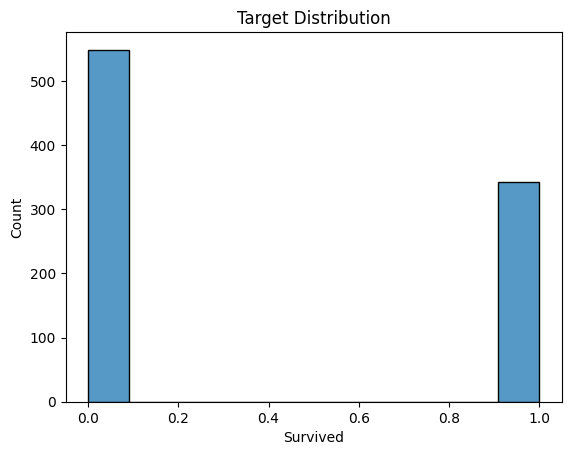

Skew_val : 0.4785234382949897
Balance_Check : Survived
0    549
1    342
Name: count, dtype: int64


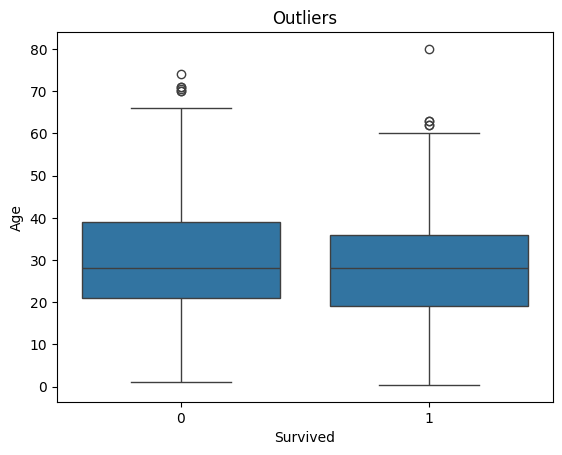

Outliers 0


In [5]:
target ='Survived'

# EDA VISUALISATION:
# 1 Target Analysis:

sns.histplot(x=df[target])
plt.title('Target Distribution')
plt.show()

skew_val = df[target].skew() # checking Skew
print('Skew_val :',skew_val) # we are going to fix the skew in the main coding file.

bal_check =df[target].value_counts() # Imbalance check
print('Balance_Check :',bal_check) # --- fix in the main file


# 2 Target Outliers:
sns.boxplot(x=df[target], y=df['Age'])
plt.title('Outliers')
plt.show()

Q1 = df[target].quantile(0.25) # Fixing Outliers
Q3 = df[target].quantile(0.75)

IQR = Q3 - Q1

upper = Q1 - 1.5 * IQR
lower = Q3 + 1.5 * IQR

outliers = df[(df[target] >= lower) | (df[target] <= upper)]
print('Outliers',len(outliers)) # After fixing we have 0 Outliers



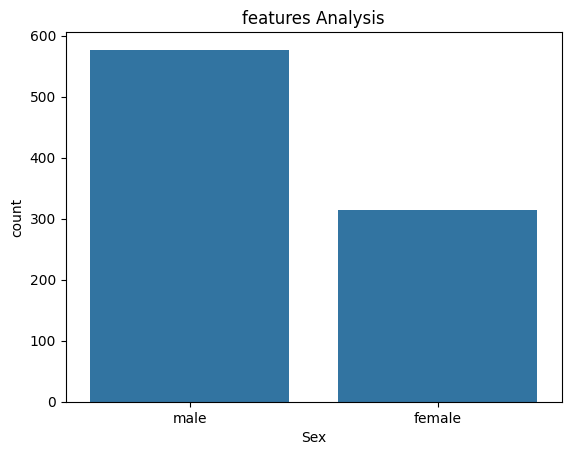

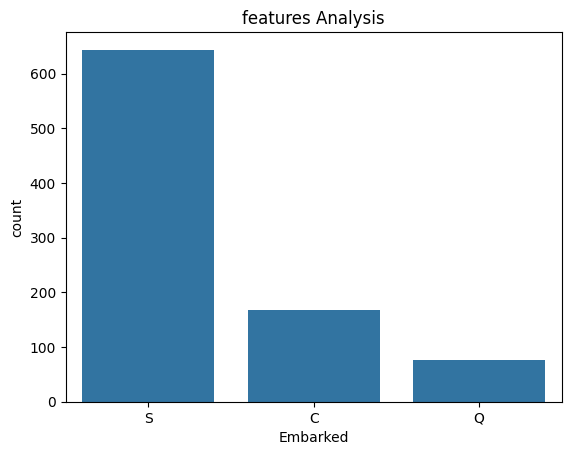

In [6]:
# 3  Categorical Feature Analysis :
cat_col = df.select_dtypes(include='str').columns

for col in cat_col:
    if col != target:
        sns.countplot(x=df[col])
        plt.title('features Analysis')
        plt.show()

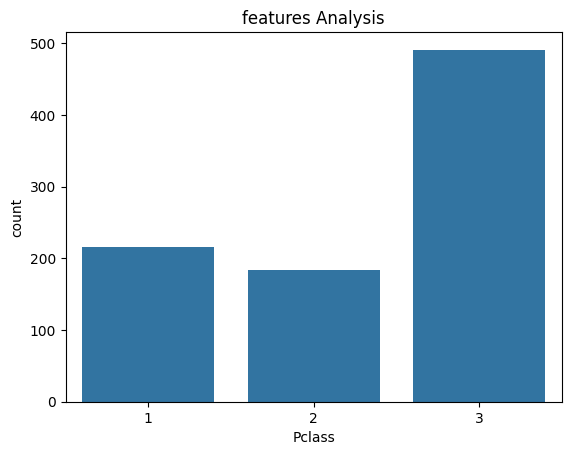

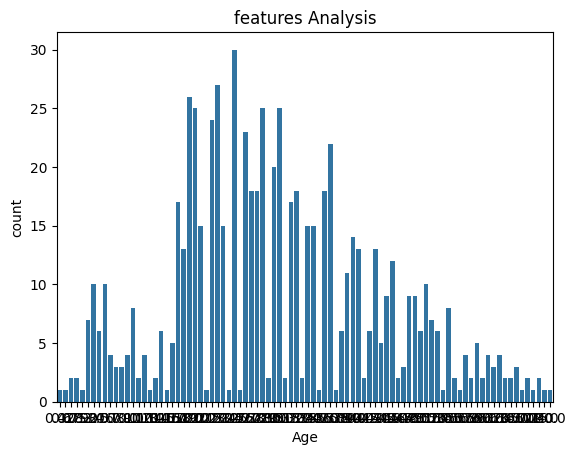

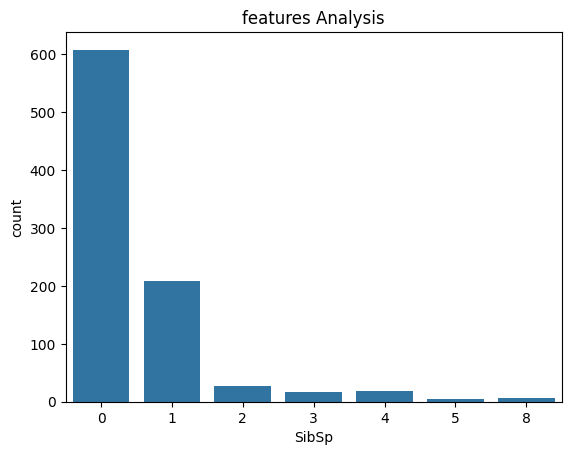

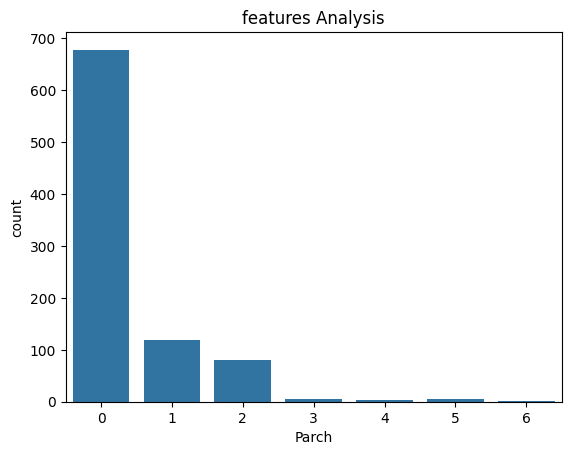

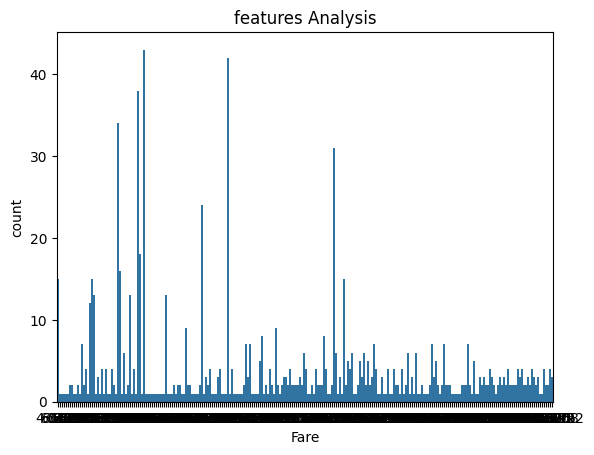

In [10]:
# 4  Numerical Feature Analysis :
num_col = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_col:
    if col != target:
        sns.countplot(x=df[col])
        plt.title('features Analysis')
        plt.show() # we can see that ['Age', 'Fare'] are skewed

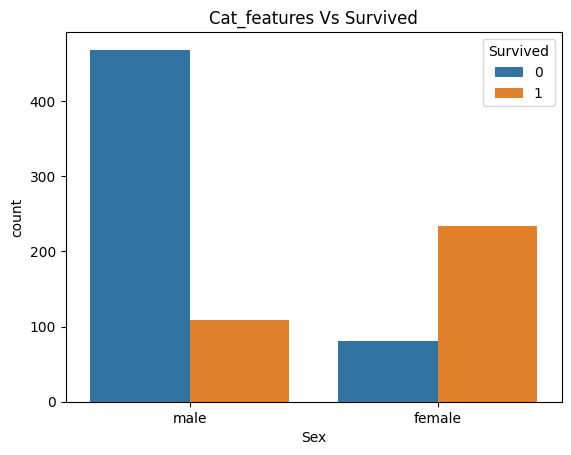

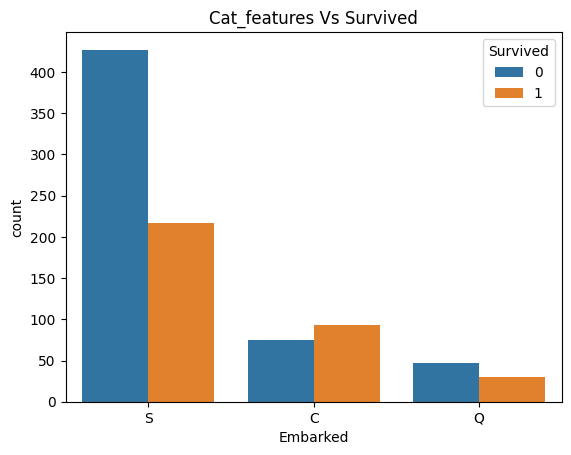

In [11]:
# 5 Feature vs target Analysis:
# Categorical -
for col in cat_col:
    sns.countplot(x=col, hue='Survived', data=df)
    plt.title('Cat_features Vs Survived')
    plt.show()


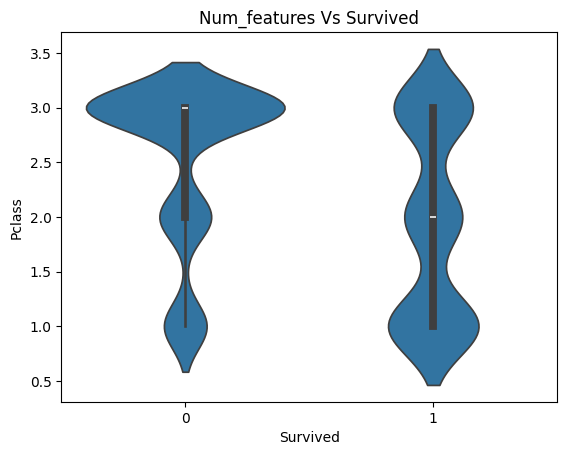

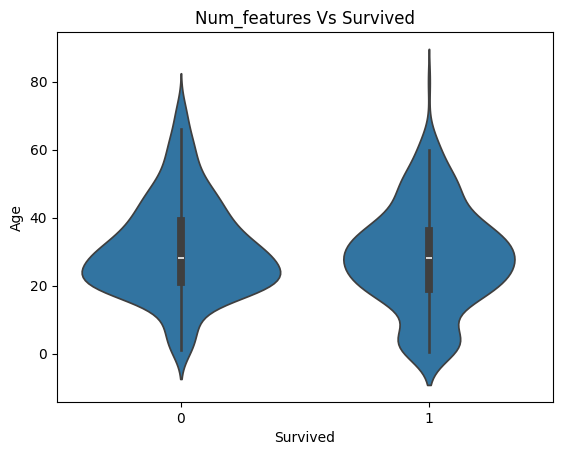

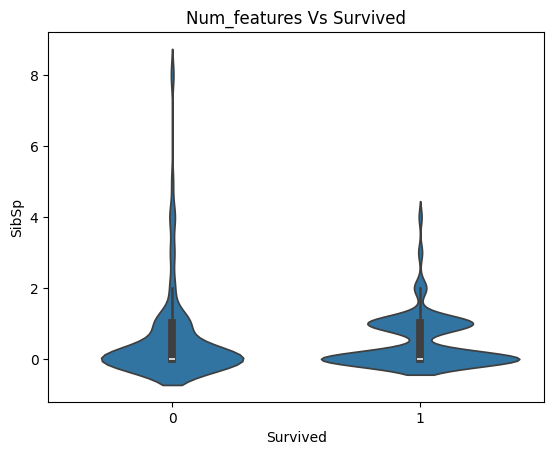

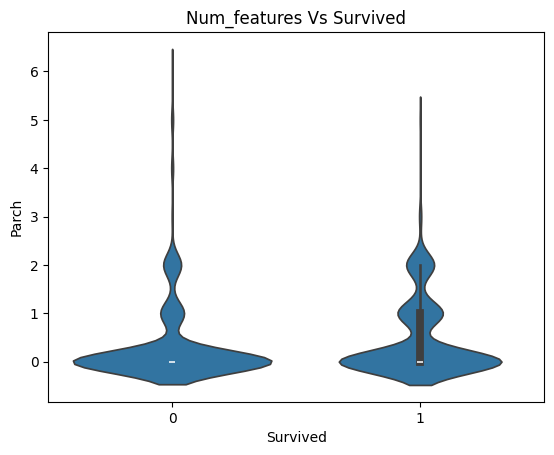

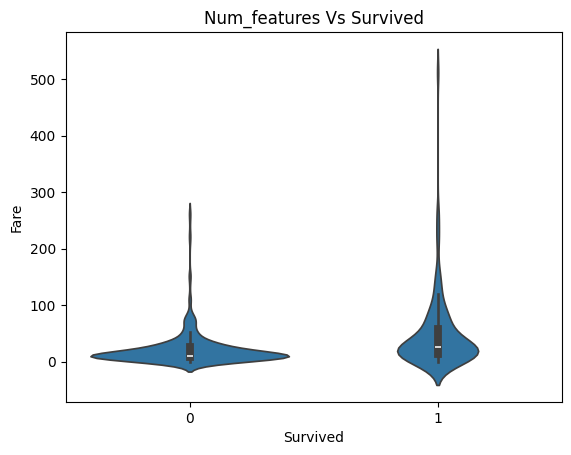

In [12]:
# Numerical -
for col in num_col:
    if col != target:
        sns.violinplot(x='Survived', y=col, data=df)
        plt.title('Num_features Vs Survived')
        plt.show()

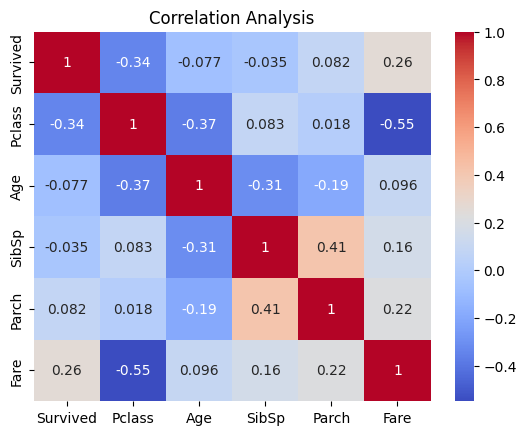

In [13]:
# Correlation Analysis:

corr = df[num_col].corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Analysis')
plt.show()